In [1]:
import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
import pandas as pd
import numpy as np
import scanpy as sc

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt

large_data_dir = gf_utils.large_data_dir

In [ ]:
gf_dir = large_data_dir + 'gf_CL3_GapLength_Beta_HB_4plex/'
test_probes = pd.DataFrame()
for lib in ['1','2','3','4']:
    manifest = gf_utils.get_manifest(gf_dir + 'BC' + lib + '_giftwrap/')
    control_probes = manifest.loc[manifest['name'].str.contains('0bp')]
    test_probes = pd.concat([test_probes, manifest.loc[~(manifest['name'].str.contains('0bp')) & ~(manifest['gapfill_start'].isna())]])


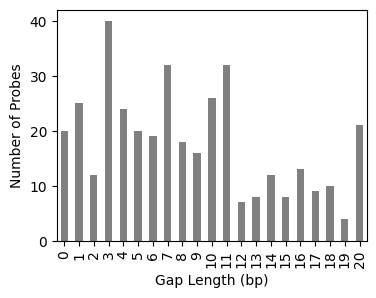

In [3]:
fig,ax = plt.subplots(figsize=(4,3))
test_probes['gapfill_from_transcriptome'].fillna('').str.len().value_counts().sort_index().plot.bar(ax=ax, color='grey')

ax.set_ylabel('Number of Probes')
ax.set_xlabel('Gap Length (bp)')

plt.savefig('../plots/gap_length_design.pdf')